In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

#### Loading the test set 

In [2]:
# Setup paths for the test set
base_dir = os.path.abspath('../data/processed')
test_dir = os.path.join(base_dir, 'test')

IMG_SIZE = 150
BATCH_SIZE = 32

# here, obviously, no augmentation is inserted
test_datagen = ImageDataGenerator(rescale=1./255)

print(f"Loading Test Data from: {test_dir}")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # False because the order of the images must match the order of the true labels for testing
)

# class labels for the evaluation
class_labels = list(test_generator.class_indices.keys())

Loading Test Data from: /Users/paolominini/Projects/rps-cnn-classifier/data/processed/test
Found 331 images belonging to 3 classes.


### Evaluation 

#### Function for the evaluation

In [3]:
def evaluate_model(model_path, model_name, generator):
    print(f"\n{'='*50}")
    print(f"Evaluating {model_name} on Test Set")
    print(f"{'='*50}")
    
    # Load the model to test
    model = tf.keras.models.load_model(model_path)
    
    # Dynamically grab class labels from the generator
    class_labels = list(generator.class_indices.keys())
    
    # Get predictions and true labels
    generator.reset()  # Start from the first image
    predictions = model.predict(generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = generator.classes
    
    # Print the metrics
    print("\n--- Classification Report ---")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels))
    
    # Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Save the figures
    os.makedirs('../reports/figures', exist_ok=True)
    plt.savefig(f'../reports/figures/confusionmat_{model_name}.png')
    plt.show()
        
    return true_classes, predicted_classes

#### Actual evaluation of models


Evaluating Model 1 (Baseline) on Test Set
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step

--- Classification Report ---
              precision    recall  f1-score   support

       paper       1.00      0.94      0.97       108
        rock       0.96      1.00      0.98       110
    scissors       0.97      0.99      0.98       113

    accuracy                           0.98       331
   macro avg       0.98      0.98      0.98       331
weighted avg       0.98      0.98      0.98       331



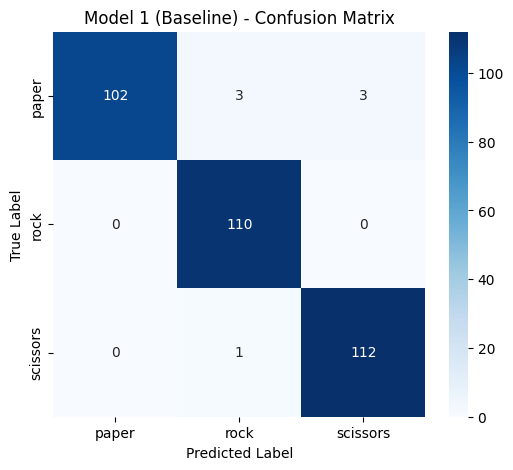


Evaluating Model 2 (Deep CNN) on Test Set
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step

--- Classification Report ---
              precision    recall  f1-score   support

       paper       0.98      0.99      0.99       108
        rock       0.99      0.98      0.99       110
    scissors       1.00      1.00      1.00       113

    accuracy                           0.99       331
   macro avg       0.99      0.99      0.99       331
weighted avg       0.99      0.99      0.99       331



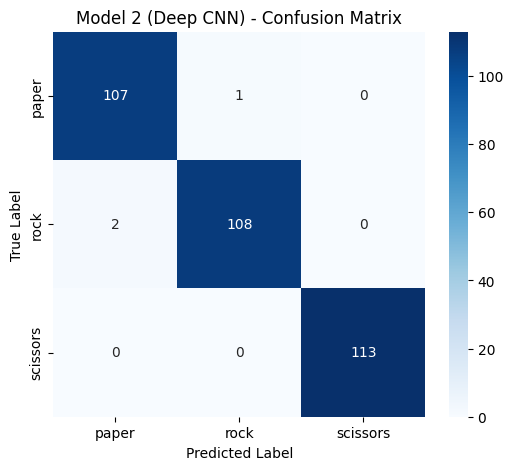


Evaluating Model 3 (Tuned Model) on Test Set
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step

--- Classification Report ---
              precision    recall  f1-score   support

       paper       0.98      0.96      0.97       108
        rock       1.00      0.98      0.99       110
    scissors       0.97      1.00      0.98       113

    accuracy                           0.98       331
   macro avg       0.98      0.98      0.98       331
weighted avg       0.98      0.98      0.98       331



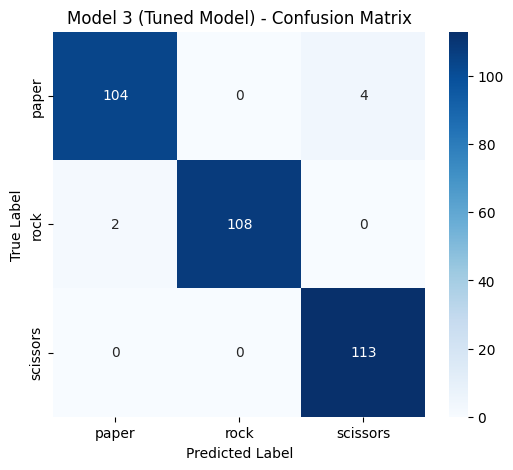

In [4]:
# Evaluate Model 1
y_true_1, y_pred_1 = evaluate_model('../models/model_1.keras', 'Model 1 (Baseline)', test_generator)

# Evaluate Model 2
y_true_2, y_pred_2 = evaluate_model('../models/deep_model.keras', 'Model 2 (Deep CNN)', test_generator)

# Evaluate Model 3
y_true_3, y_pred_3 = evaluate_model('../models/tuned_model.keras', 'Model 3 (Tuned Model)', test_generator)

#### Missclassification Analysis

In [5]:
def plot_test_mistakes(true_classes, predicted_classes, generator, model_name):
    # Find the indices where predictions don't match true labels
    errors = np.where(predicted_classes != true_classes)[0]
    
    if len(errors) > 0:
        print(f"\n{model_name} made {len(errors)} mistakes on the Test Set. Plotting up to 10...")
        
        # We will show up to 10 errors
        num_to_show = min(10, len(errors))
        plt.figure(figsize=(15, 6))
        
        for i in range(num_to_show):
            error_index = errors[i]
            
            # Get the actual image file path from the test generator
            image_path = generator.filepaths[error_index]
            
            # Load and plot
            img = plt.imread(image_path)
            plt.subplot(2, 5, i+1)
            plt.imshow(img)
            
            # Extract labels
            pred_label = class_labels[predicted_classes[error_index]]
            true_label = class_labels[true_classes[error_index]]
            
            plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color='red', fontweight='bold')
            plt.axis('off')
            
        plt.suptitle(f"{model_name} - Test Set Misclassifications", fontsize=16)
        plt.tight_layout()
        
        # Save the figure for your report!
        os.makedirs('../reports/figures', exist_ok=True)
        safe_name = model_name.replace(" ", "_").replace(":", "").lower()
        plt.savefig(f'../reports/figures/test_mistakes_{safe_name}.png')
        
        plt.show()
    else:
        print(f"{model_name} made ZERO mistakes on the test set!")


Model 1 (Baseline) made 7 mistakes on the Test Set. Plotting up to 10...


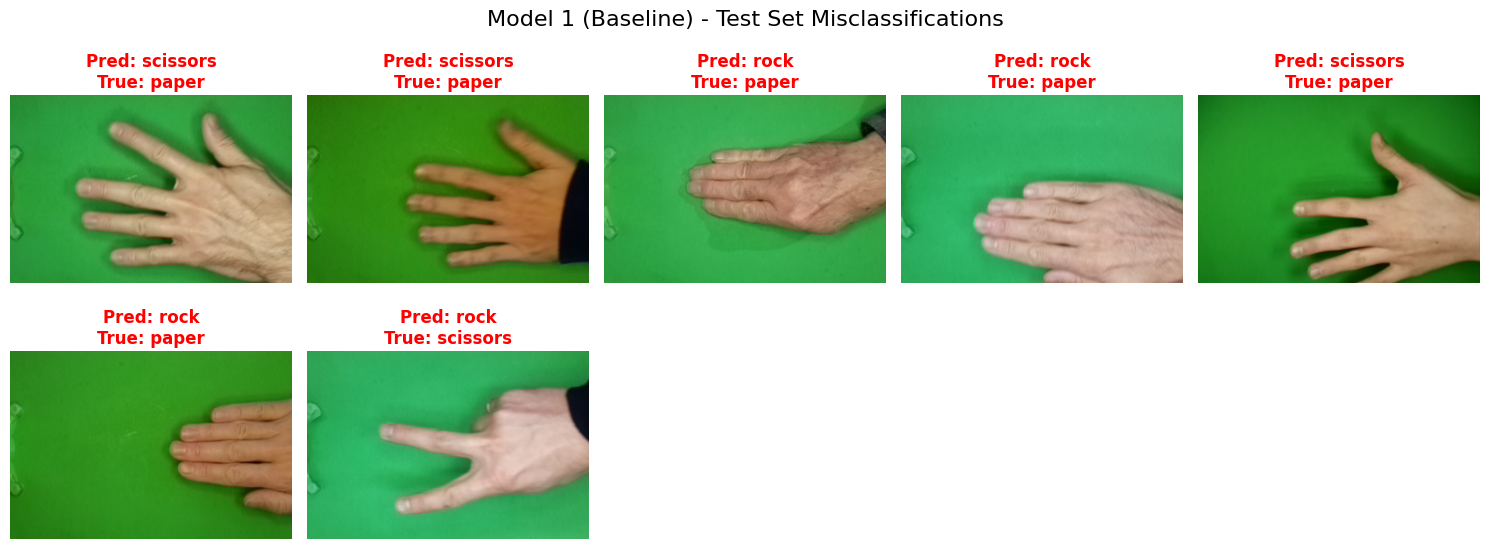


Model 2 (Deep CNN) made 3 mistakes on the Test Set. Plotting up to 10...


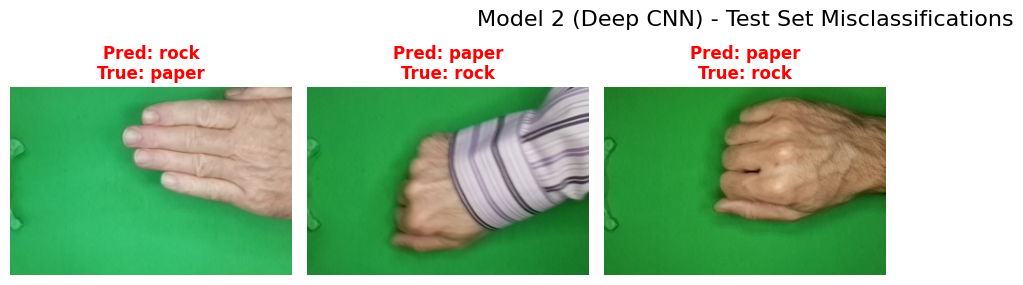


Model 3 (Tuned) made 6 mistakes on the Test Set. Plotting up to 10...


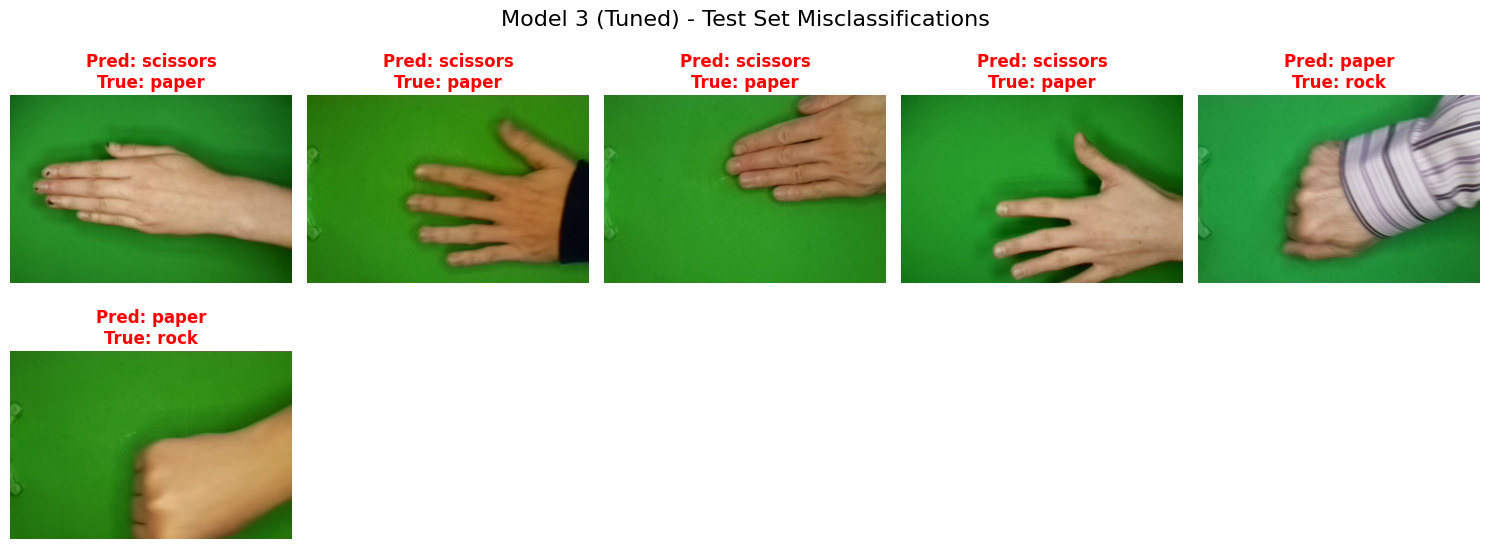

In [6]:
plot_test_mistakes(y_true_1, y_pred_1, test_generator, 'Model 1 (Baseline)')
plot_test_mistakes(y_true_2, y_pred_2, test_generator, 'Model 2 (Deep CNN)')
plot_test_mistakes(y_true_3, y_pred_3, test_generator, 'Model 3 (Tuned)')

#### Test Set Evaluation & Metric Analysis

We evaluated all three models on a strictly held-out test set of 331 images. Because this test set is "in-distribution" (featuring the same uniform green background and lighting as the training set), it tests how well the models mapped the specific features of the original dataset.

**1. Model 1 (Baseline) - Accuracy: 98%**
* **Performance:** Our shallow architecture performed exceptionally well, achieving an overall accuracy of 98%. 
* **Key Insight:** Looking at the class breakdown, we see a **Recall of 0.94 for Paper**, which is its lowest metric. This means Model 1 missed 6% of the actual 'Paper' images (likely misclassifying them as Rock or Scissors). However, its **Precision for Paper is 1.00**, meaning when it *did* predict Paper, it was 100% correct. It is cautious but highly accurate when confident.

**2. Model 2 (Deep Unregularized) - Accuracy: 99%**
* **Performance:** This model is the clear winner on the in-distribution test set, achieving a near-perfect 99% accuracy and a flawless 1.00 F1-score on the 'Scissors' class.
* **Key Insight:** Why did this model perform the best here? Because it has a massive parameter capacity (512 Dense units) and no Dropout. It was allowed to use 100% of its neurons to perfectly memorize the clean, uniform features of the dataset's green-screen environment. It is the ultimate "in-distribution" champion.

**3. Model 3 (Tuned & Regularized) - Accuracy: 98%**
* **Performance:** The tuned model achieved 98% accuracy, matching the baseline but slightly underperforming the unregularized Model 2 on this specific test set.
* **Key Insight:** This slight dip in accuracy (from 99% to 98%) is the **mathematical cost of regularization**. Because Model 3 uses aggressive 50% Dropout, we intentionally handicapped its ability to memorize the specific pixels of the dataset's green background. It traded a tiny fraction of in-distribution accuracy to ensure it learned robust, generalizable geometric shapes instead. Notice its perfect **Precision (1.00) on Rock** and perfect **Recall (1.00) on Scissors**.

#### Conclusion on Test Set Performance
If our goal was strictly to perform well on images from this specific green-screen dataset, **Model 2** is the optimal choice due to its sheer capacity. However, as noted in previous phases, Model 2's lack of regularization makes it theoretically brittle. **Model 3** sacrifices a marginal 1% of accuracy on this perfectly clean test set to maintain structural robustness, representing a much safer architecture for real-world deployment.

### Generalization Test (Out-of-Distribution Data)
To test if our models truly learned the geometric shapes of hands and didn't just memorize the dataset's green background, we will evaluate it on newly captured images of personal hands in different environments.

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppresses all TF Info and Warning messages

# Setup paths and find images
custom_dir = '../data/custom/'
image_files = [f for f in os.listdir(custom_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not image_files:
    print("No images found in '../data/custom/'. Please add some images and try again.")
else:
    batch_images = []
    display_images = []
    true_labels = []
    
    # Load images and extract TRUE labels from filenames
    for filename in image_files:
        img_path = os.path.join(custom_dir, filename)
        
        current_true_label = "Unknown"
        for label in class_labels:
            if label.lower() in filename.lower():
                current_true_label = label
                break
        true_labels.append(current_true_label)
        
        img = image.load_img(img_path, target_size=(150, 150))
        display_images.append(img)
        
        img_array = image.img_to_array(img)
        img_array /= 255.0 
        batch_images.append(img_array)
        
    batch_tensor = np.array(batch_images)
    total_custom_images = len(image_files)
    print(f"Loaded {total_custom_images} custom images for OOD testing.")

    # Define the models to test
    models_to_test = {
        'Model 1: Baseline': '../models/model_1.keras',
        'Model 2: Deep Unregularized': '../models/deep_model.keras',
        'Model 3: Tuned & Regularized': '../models/tuned_model.keras'
    }

    import math # Make sure to add this import at the top!


    # Predict and Compare
    for model_name, model_path in models_to_test.items():
        print(f"\nEvaluating {model_name}...")
        try:
            model = tf.keras.models.load_model(model_path)
            predictions = model.predict(batch_tensor, verbose=0)
            
            correct_predictions = 0
            
            # Loop through predictions to calculate accuracy
            for i in range(total_custom_images):
                # Get the index of the highest probability
                pred_class_idx = np.argmax(predictions[i])
                pred_label = class_labels[pred_class_idx]
                true_label = true_labels[i]

                if true_label != "Unknown" and pred_label.lower() == true_label.lower():
                    correct_predictions += 1
            
            # Calculate and print the final accuracy
            ood_accuracy = (correct_predictions / total_custom_images) * 100
            print(f"👉 {model_name} OOD Accuracy: {correct_predictions}/{total_custom_images} ({ood_accuracy:.1f}%)")
            
        except OSError:
            print(f"Could not load {model_path}. Make sure the file exists.")

Loaded 42 custom images for OOD testing.

Evaluating Model 1: Baseline...
👉 Model 1: Baseline OOD Accuracy: 19/42 (45.2%)

Evaluating Model 2: Deep Unregularized...
👉 Model 2: Deep Unregularized OOD Accuracy: 14/42 (33.3%)

Evaluating Model 3: Tuned & Regularized...
👉 Model 3: Tuned & Regularized OOD Accuracy: 24/42 (57.1%)
